# (01) poisson + BALLS16: (16, 8.0)

project = ```iP-VAE```, host = ```chewie```, device = ```cuda:1```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: yoru

## Trainer

In [3]:
model_type = 'poisson'
npix = 16
cfg_vae, cfg_tr = default_configs(model_type, f'BALLS{npix}')

cfg_vae['n_latents'] = int(npix * 2)

cfg_vae['seq_len'] = 16
cfg_tr['kl_beta'] = 8.0

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |   8.5 K    |
|     ———     |    ———     |
|    layer    |   8.5 K    |
+-------------+------------+

poisson_BALLS16_t-16_z-[32]_u-10,du-10_<grad|lin>
b400-ep1000-lr(0.0005)_beta(8:0.1)_temp(0.01:0.5)_gr(5000)_(2025_03_05,23:40)

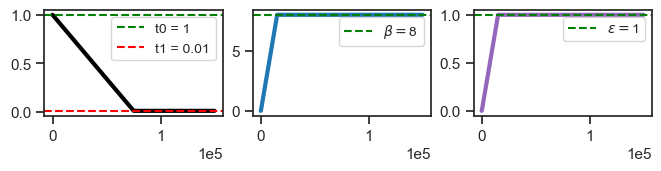

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [5]:
tr.n_iters

150000

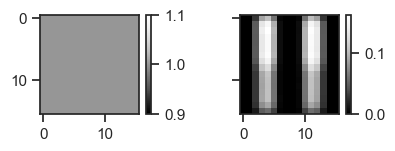

In [6]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(16, 16)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

In [7]:
print(tr.model.layer)

PoissonLayer(input_dim=256, latent_dim=32, temperature=1, beta_inner=1, eps=1)

In [8]:
# tr.model.layer.update_n_exp(18.5)
print(tr.model.layer.n_exp)

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:1', dtype=torch.int32)

In [9]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([1.], device='cuda:1', grad_fn=<ExpBackward0>),)

In [10]:
# cm = ''
# tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

tr.train()

epoch # 1000, avg loss: -433.679: 100%|███| 1000/1000 [1:43:17<00:00,  6.20s/it]


In [11]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.0743], device='cuda:1', grad_fn=<ExpBackward0>),)

In [12]:
print(tr.model.layer.n_exp)

tensor([151, 183, 209, 229, 249, 266, 276, 284, 290, 292, 293, 294, 294, 295,
        296, 295], device='cuda:1', dtype=torch.int32)

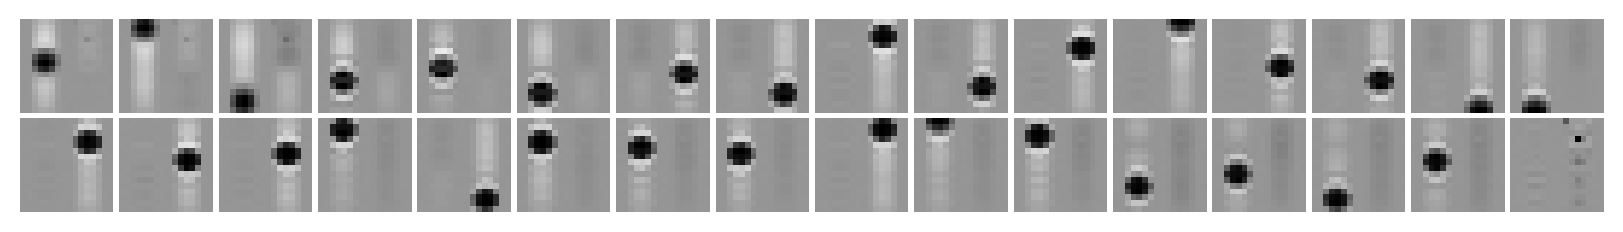

In [13]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0), nrows=2, method='abs-max');

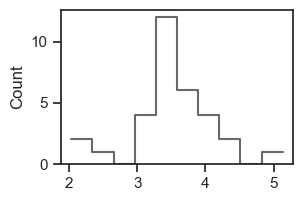

In [14]:
histplot(u0, color='dimgrey')
plt.show()

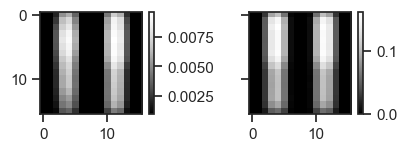

In [15]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(16, 16)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

100%|███████████████████████████████████| 5/5 [00:09<00:00,  1.85s/it]


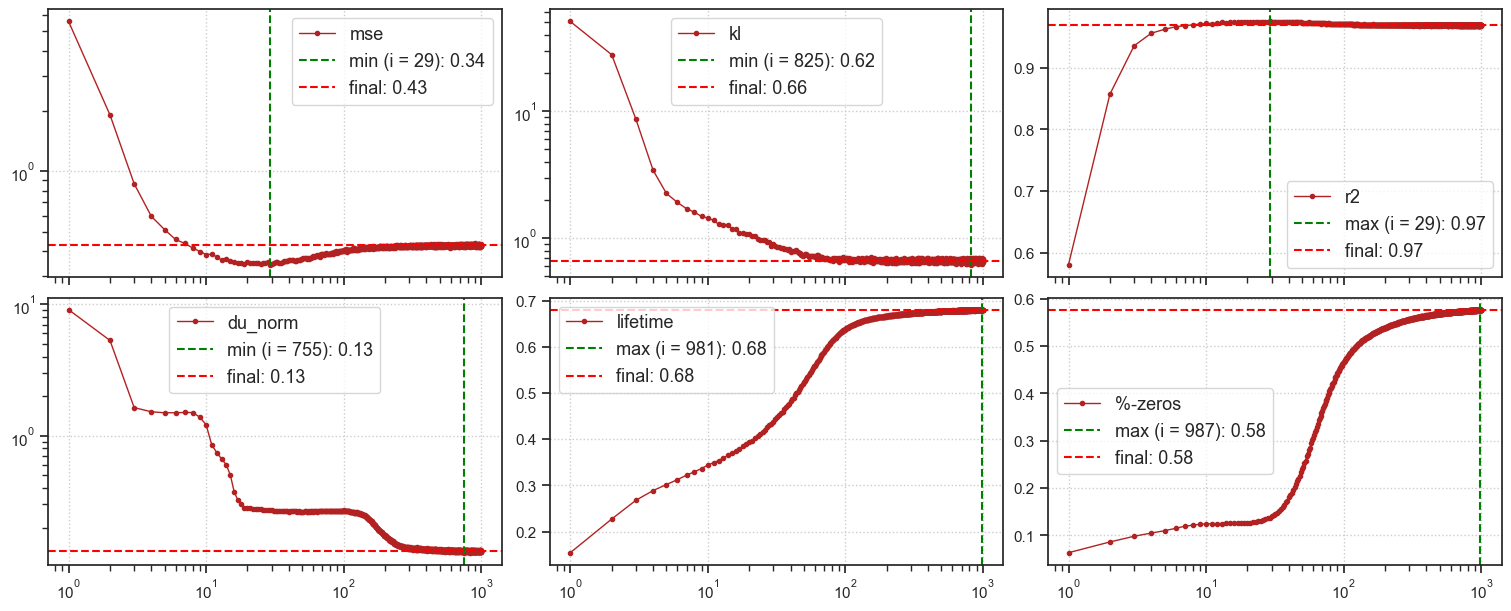

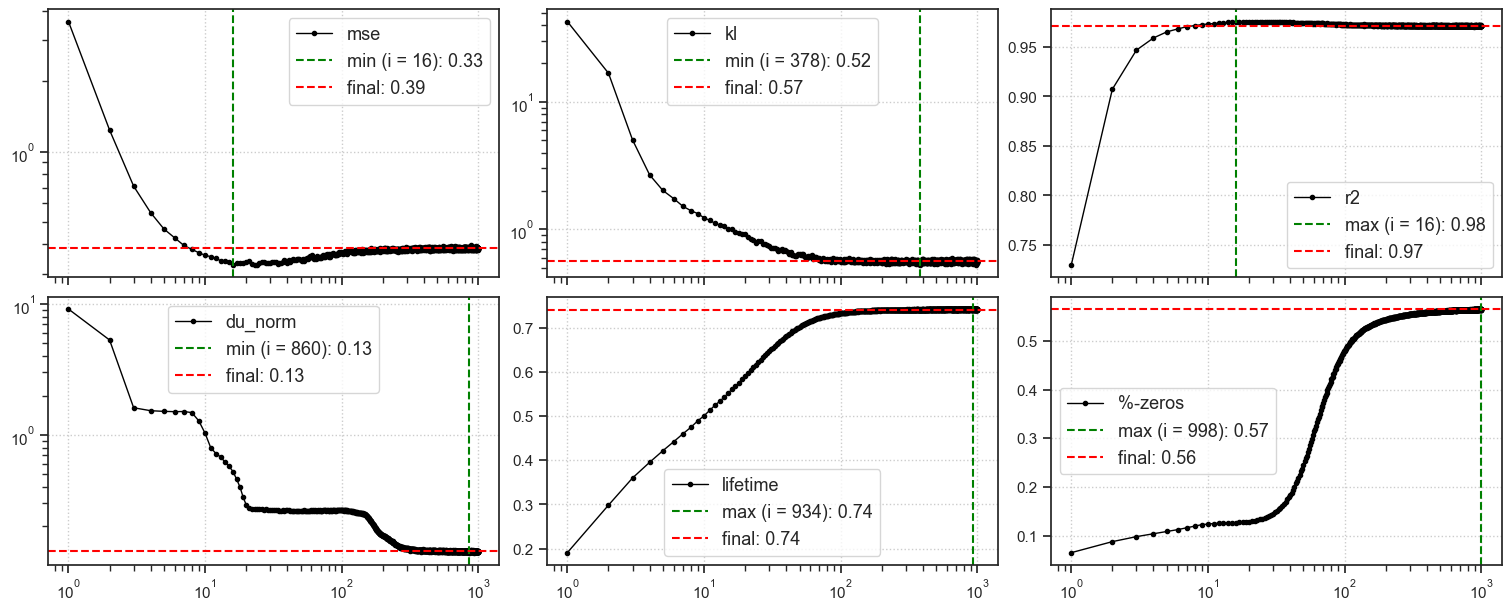

CPU times: user 21.2 s, sys: 276 ms, total: 21.4 s
Wall time: 21.4 s


In [16]:
%%time

kws = dict(
    seq_total=1000,
    seq_batch_sz=1000,
    n_data_batches=5,
)
results = {
    k: tr.analysis(k, **kws)
    for k in ['tst', 'vld']
}
# plot
_ = plot_convergence(results['tst'], color='firebrick')
_ = plot_convergence(results['vld'], color='k')

In [17]:
from analysis.linreg import untangle_score

output = untangle_score(tr, seq_total=1000, seq_batch_sz=100)

100%|███████████████████████████████| 125/125 [03:47<00:00,  1.82s/it]


In [18]:
print(f"r2 tst:", output['r2_zg']['tst'])

r2 tst:
{
    1: array([0.8053962 , 0.87792075], dtype=float32),
    100: array([0.9742877, 0.9729233], dtype=float32),
    200: array([0.97419316, 0.9724701 ], dtype=float32),
    300: array([0.97447574, 0.9721634 ], dtype=float32),
    400: array([0.9745065 , 0.97223455], dtype=float32),
    500: array([0.97443026, 0.97239524], dtype=float32),
    600: array([0.97428346, 0.97151655], dtype=float32),
    700: array([0.9751514, 0.9719847], dtype=float32),
    800: array([0.97428495, 0.9722785 ], dtype=float32),
    900: array([0.97465  , 0.9723934], dtype=float32),
    1000: array([0.9743946 , 0.97208446], dtype=float32)
}